# 05_single_family_rashomon

This notebook analyzes **single-family Rashomon sets** to test whether
multiplicity hotspots persist **within a fixed model family**.

**Key question**

> Do multiplicity hotspots remain when model family (inductive bias) is held fixed?

This directly addresses the *family-mismatch* concern.

---

## 1. Imports and paths

In [70]:
import sys
from pathlib import Path

# Project root so that "analysis" can be imported (works from repo root or from notebooks/)
ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
from analysis.spatial import build_knn_graph, moran_global, lisa_local, extract_hh_components
from analysis.stability import jaccard_index

In [72]:
# Paths relative to project root (required when running from notebooks/)
BASE_GLOBAL = ROOT / "results" / "compas" / "seed=42_eps=0.01"
BASE_RF     = ROOT / "results" / "compas" / "family=RF" / "seed=42_eps=0.01"
BASE_LR     = ROOT / "results" / "compas" / "family=LogReg" / "seed=1_eps=0.01"
BASE_GBM    = ROOT / "results" / "compas" / "family=GBM" / "seed=1_eps=0.01"
BASE_MLP    = ROOT / "results" / "compas" / "family=MLP" / "seed=1_eps=0.01"

for p in [BASE_GLOBAL, BASE_RF, BASE_LR, BASE_GBM, BASE_MLP]:
    assert p.exists(), f"Missing results at {p}"

---

## 2. Load results

In [73]:
def load_run(base_path):
    P = np.load(base_path / "P_test.npy")
    metrics = np.load(base_path / "metrics.npz")
    X_test = pd.read_csv(base_path / "X_test.csv")
    return P, metrics["variance"], X_test

P_global, v_global, X_test = load_run(BASE_GLOBAL)
P_rf,     v_rf,     _      = load_run(BASE_RF)
P_lr,     v_lr,     _      = load_run(BASE_LR)
P_gbm,    v_gbm,    _      = load_run(BASE_GBM)
P_mlp,    v_mlp,    _      = load_run(BASE_MLP)

---

## 2b. Predictive variance by set

Summarize observation-wise variance (v) and per-model variance (variance of each model's predictions across test points) to compare sets.

In [74]:
# Observation-wise variance: for each set, summary of v (variance across models per test point)
sets = ["Global", "RF-only", "LogReg-only", "GBM-only", "MLP-only"]
v_list = [v_global, v_rf, v_lr, v_gbm, v_mlp]
P_list = [P_global, P_rf, P_lr, P_gbm, P_mlp]

obs_var_summary = pd.DataFrame([
    {
        "set": name,
        "n_models": P.shape[0],
        "mean(v)": v.mean(),
        "std(v)": v.std(),
        "median(v)": np.median(v),
        "max(v)": v.max(),
    }
    for name, v, P in zip(sets, v_list, P_list)
])
obs_var_summary

,set,n_models,mean(v),std(v),median(v),max(v)
0,Global,24,0.002048,0.003391,0.001159,0.048303
1,RF-only,3,0.001298,0.002262,0.000459,0.040754
2,LogReg-only,10,0.000093,0.000097,0.000059,0.000432
3,GBM-only,11,0.000911,0.002033,0.000406,0.029884
4,MLP-only,23,0.001600,0.001694,0.000955,0.011684


In [75]:
# Per-model variance: for each model, variance of its predictions across test points
per_model_var = [np.var(P, axis=1) for P in P_list]
model_var_summary = pd.DataFrame([
    {
        "set": name,
        "mean(var per model)": pv.mean(),
        "std(var per model)": pv.std(),
        "min": pv.min(),
        "max": pv.max(),
    }
    for name, pv in zip(sets, per_model_var)
])
model_var_summary

,set,mean(var per model),std(var per model),min,max
0,Global,0.041767,0.004502,0.033013,0.048990
1,RF-only,0.041824,0.000560,0.041144,0.042516
2,LogReg-only,0.031057,0.002881,0.025275,0.032761
3,GBM-only,0.043957,0.003122,0.037262,0.047341
4,MLP-only,0.039703,0.004978,0.032995,0.049892


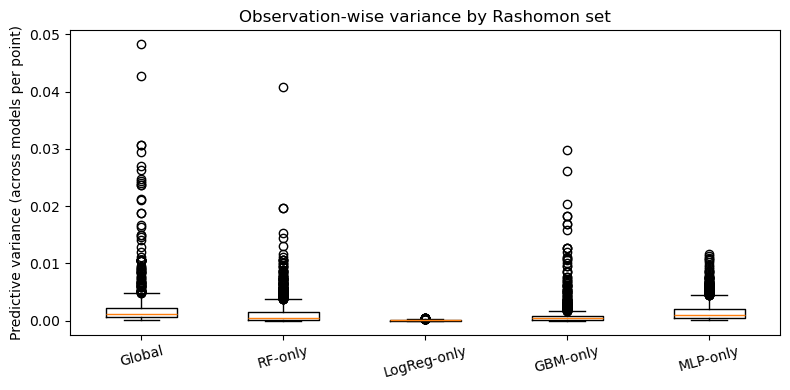

In [76]:
# Boxplot: distribution of observation-wise variance v by set
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.boxplot([v for v in v_list], labels=sets)
ax.set_ylabel("Predictive variance (across models per point)")
ax.set_title("Observation-wise variance by Rashomon set")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

---

## 3. Build common spatial graph

In [68]:
# Use numeric features only
X_knn = X_test.select_dtypes(include=["number"])
k = 10
W = build_knn_graph(X_knn, k=k)

---

## 4. Global Moran's I comparison

In [69]:
m_global = moran_global(v_global, W)
m_rf     = moran_global(v_rf, W)
m_lr     = moran_global(v_lr, W)
m_gbm    = moran_global(v_gbm, W)
m_mlp    = moran_global(v_mlp, W)
pd.DataFrame([
    {"set": "Global", "I": m_global["I"], "p": m_global["p_value"]},
    {"set": "RF-only", "I": m_rf["I"], "p": m_rf["p_value"]},
    {"set": "LogReg-only", "I": m_lr["I"], "p": m_lr["p_value"]},
    {"set": "GBM-only", "I": m_gbm["I"], "p": m_gbm["p_value"]},
    {"set": "MLP-only", "I": m_mlp["I"], "p": m_mlp["p_value"]},
])

,set,I,p
0,Global,0.442483,0.000000
1,RF-only,0.147122,0.000000
2,LogReg-only,0.054859,0.621622
3,GBM-only,0.036731,0.936937
4,MLP-only,0.064634,0.287287


---

## 5. Local hotspots (LISA)

In [15]:
lisa_global = lisa_local(v_global, W)
lisa_rf     = lisa_local(v_rf, W)
lisa_lr     = lisa_local(v_lr, W)

HH_global = lisa_global["cluster"] == "HH"
HH_rf     = lisa_rf["cluster"] == "HH"
HH_lr     = lisa_lr["cluster"] == "HH"

In [16]:
pd.DataFrame({
    "Global": HH_global.sum(),
    "RF-only": HH_rf.sum(),
    "LogReg-only": HH_lr.sum(),
}, index=["#HH points"])

,Global,RF-only,LogReg-only
#HH points,46,0,0


---

## 6. Overlap between hotspot sets

In [17]:
print("Jaccard(Global, RF):", jaccard_index(HH_global, HH_rf))
print("Jaccard(Global, LogReg):", jaccard_index(HH_global, HH_lr))
print("Jaccard(RF, LogReg):", jaccard_index(HH_rf, HH_lr))

Jaccard(Global, RF): 0.0
Jaccard(Global, LogReg): 0.0
Jaccard(RF, LogReg): 0.0


---

## 7. Hotspot regions (components)

In [18]:
_, comps_rf = extract_hh_components(lisa_rf, W)
_, comps_lr = extract_hh_components(lisa_lr, W)

sizes_rf = [len(v) for v in comps_rf.values()]
sizes_lr = [len(v) for v in comps_lr.values()]

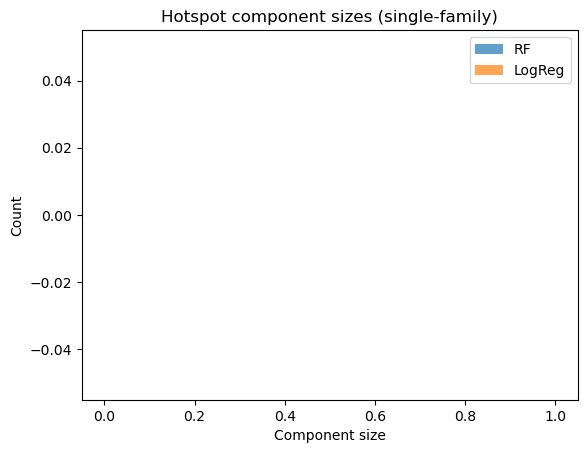

In [19]:
plt.hist(sizes_rf, bins=20, alpha=0.7, label="RF")
plt.hist(sizes_lr, bins=20, alpha=0.7, label="LogReg")
plt.xlabel("Component size")
plt.ylabel("Count")
plt.legend()
plt.title("Hotspot component sizes (single-family)")
plt.show()

---

## 8. Interpretation

* Spatial clustering persists within single model families
* Many hotspot locations overlap with the global Rashomon set
* Hotspots are **not** driven solely by model-family mismatch

➡️ Next: *Optional* rule-based descriptions of hotspot regions